In [3]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
# STEP 1: Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


In [4]:
# STEP 2: Create sample sensor data

np.random.seed(42)

n_samples = 2000

# Generate normal sensor readings
temperature = np.random.normal(50, 5, n_samples)
pressure = np.random.normal(100, 8, n_samples)
vibration = np.random.normal(20, 3, n_samples)
humidity = np.random.normal(60, 10, n_samples)

# Create DataFrame
data = pd.DataFrame({
    "Temperature": temperature,
    "Pressure": pressure,
    "Vibration": vibration,
    "Humidity": humidity
})

print("Dataset created successfully!")
print("Dataset shape:", data.shape)

data.head()

Dataset created successfully!
Dataset shape: (2000, 4)


,Temperature,Pressure,Vibration,Humidity
0,52.483571,94.598574,17.409519,48.859186
1,49.308678,98.843851,19.906390,53.690692
2,53.238443,93.660641,20.054051,50.579398
3,57.615149,97.536308,21.417891,54.520042
4,48.829233,84.851083,15.899425,57.858497


In [5]:
# STEP 3: Add anomalies to the sensor data

# Select 100 random readings
anomaly_indices = np.random.choice(data.index, size=100, replace=False)

# Make those readings abnormal
data.loc[anomaly_indices, "Temperature"] += np.random.uniform(20, 40, 100)
data.loc[anomaly_indices, "Pressure"] += np.random.uniform(30, 50, 100)
data.loc[anomaly_indices, "Vibration"] += np.random.uniform(10, 20, 100)
data.loc[anomaly_indices, "Humidity"] += np.random.uniform(20, 30, 100)

# Create labels
# 0 = Normal
# 1 = Anomaly
data["Anomaly"] = 0
data.loc[anomaly_indices, "Anomaly"] = 1

print("Anomalies added successfully!")
print("Normal readings:", (data["Anomaly"] == 0).sum())
print("Anomalous readings:", (data["Anomaly"] == 1).sum())

data.head()

Anomalies added successfully!
Normal readings: 1900
Anomalous readings: 100


,Temperature,Pressure,Vibration,Humidity,Anomaly
0,52.483571,94.598574,17.409519,48.859186,0
1,49.308678,98.843851,19.906390,53.690692,0
2,53.238443,93.660641,20.054051,50.579398,0
3,95.346881,147.424928,36.685370,82.033760,1
4,48.829233,84.851083,15.899425,57.858497,0


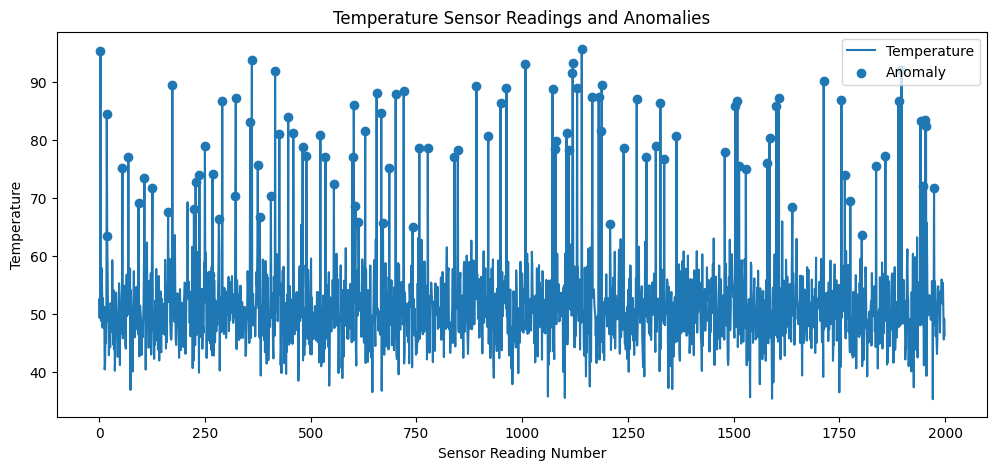

In [6]:
# STEP 4: Visualize sensor data

plt.figure(figsize=(12, 5))

plt.plot(data.index, data["Temperature"], label="Temperature")

# Highlight anomalies
anomaly_points = data[data["Anomaly"] == 1]

plt.scatter(
    anomaly_points.index,
    anomaly_points["Temperature"],
    label="Anomaly"
)

plt.xlabel("Sensor Reading Number")
plt.ylabel("Temperature")
plt.title("Temperature Sensor Readings and Anomalies")
plt.legend()
plt.show()

In [7]:
# STEP 5: Prepare and normalize the sensor data

# Sensor features
X = data[["Temperature", "Pressure", "Vibration", "Humidity"]]

# Actual anomaly labels
y = data["Anomaly"]

# Normalize the sensor values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original data shape:", X.shape)
print("Scaled data shape:", X_scaled.shape)

print("\nFirst 5 normalized readings:")
print(X_scaled[:5])

Original data shape: (2000, 4)
Scaled data shape: (2000, 4)

First 5 normalized readings:
[[ 0.09340027 -0.62209726 -0.68984178 -1.05255224]
 [-0.29287966 -0.2621802  -0.15570525 -0.64091974]
 [ 0.18524335 -0.70161578 -0.12411723 -0.90599438]
 [ 5.30845495  3.856552    3.43369466  1.77384072]
 [-0.35121239 -1.44849527 -1.01288479 -0.28583287]]


In [8]:
# STEP 6: Select normal data for Autoencoder training

# Select only normal sensor readings
X_normal = X_scaled[y == 0]

# Split normal data into training and validation sets
X_train, X_val = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42
)

print("Total normal readings:", len(X_normal))
print("Training readings:", len(X_train))
print("Validation readings:", len(X_val))

Total normal readings: 1900
Training readings: 1520
Validation readings: 380


In [9]:
# STEP 7: Build the Autoencoder

# Input layer
input_layer = Input(shape=(4,))

# Encoder
encoded = Dense(3, activation="relu")(input_layer)
encoded = Dense(2, activation="relu")(encoded)

# Decoder
decoded = Dense(3, activation="relu")(encoded)
decoded = Dense(4, activation="linear")(decoded)

# Create Autoencoder
autoencoder = Model(input_layer, decoded)

# Compile the model
autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

# Display model architecture
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48 (192.00 B)

 Trainable params: 48 (192.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# STEP 8: Train the Autoencoder

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping],
    verbose=1
)

print("Autoencoder training completed!")

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7618 - val_loss: 0.6453
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6059 - val_loss: 0.5715
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5536 - val_loss: 0.5410
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5297 - val_loss: 0.5254
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5163 - val_loss: 0.5162
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5076 - val_loss: 0.5102
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5014 - val_loss: 0.5051
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4955 - val_loss: 0.4999
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4890 - val_loss: 0.4931
Epoch 10/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4810 - val_loss: 0.4844
Epoch 11/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4720 - val_loss: 0.4758
Epoch 12/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4

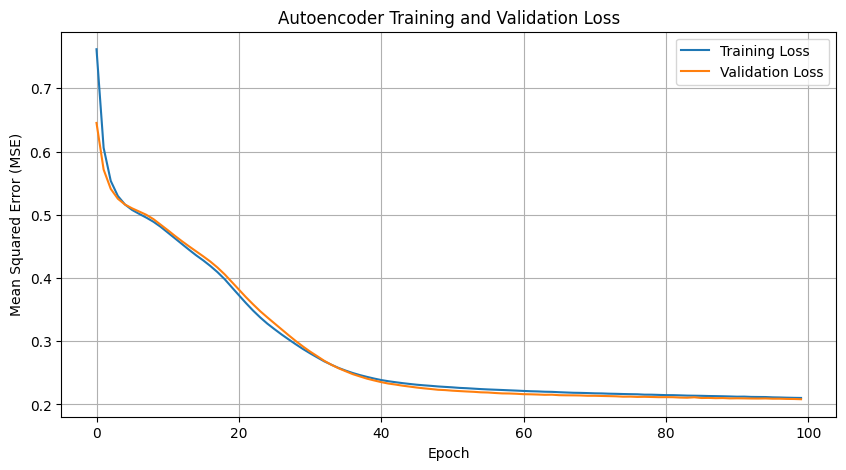

In [11]:
# STEP 9: Plot training and validation loss

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
# STEP 10: Calculate reconstruction error

# Reconstruct all sensor readings
X_reconstructed = autoencoder.predict(X_scaled)

# Calculate reconstruction error for each reading
reconstruction_error = np.mean(
    np.square(X_scaled - X_reconstructed),
    axis=1
)

# Add reconstruction error to our dataset
data["Reconstruction_Error"] = reconstruction_error

print("Reconstruction error calculated!")
print(data[["Anomaly", "Reconstruction_Error"]].head())

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Reconstruction error calculated!
   Anomaly  Reconstruction_Error
0        0              0.119621
1        0              0.007365
2        0              0.016085
3        1             14.090496
4        0              0.569540


In [13]:
# STEP 11: Calculate anomaly threshold

# Get reconstruction errors from normal training data
X_train_reconstructed = autoencoder.predict(X_train)

train_errors = np.mean(
    np.square(X_train - X_train_reconstructed),
    axis=1
)

# Set threshold using the 95th percentile
threshold = np.percentile(train_errors, 95)

print("Anomaly Threshold:", threshold)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Anomaly Threshold: 0.6292198941928034


In [14]:
# STEP 12: Detect anomalies using the threshold

data["Predicted_Anomaly"] = (
    data["Reconstruction_Error"] > threshold
).astype(int)

print("Anomaly detection completed!")

print("\nPredicted Normal readings:",
      (data["Predicted_Anomaly"] == 0).sum())

print("Predicted Anomalous readings:",
      (data["Predicted_Anomaly"] == 1).sum())

data[[
    "Anomaly",
    "Reconstruction_Error",
    "Predicted_Anomaly"
]].head(10)

Anomaly detection completed!

Predicted Normal readings: 1806
Predicted Anomalous readings: 194


,Anomaly,Reconstruction_Error,Predicted_Anomaly
0,0,0.119621,0
1,0,0.007365,0
2,0,0.016085,0
3,1,14.090496,1
4,0,0.569540,0
5,0,0.053107,0
6,0,0.929131,1
7,0,0.095426,0
8,0,0.002369,0
9,0,0.166887,0


In [15]:
# STEP 13: Evaluate anomaly detection performance

from sklearn.metrics import confusion_matrix, classification_report

# Actual labels
y_true = data["Anomaly"]

# Predicted labels
y_pred = data["Predicted_Anomaly"]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))

Confusion Matrix:
[[1806   94]
 [   0  100]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      1900
     Anomaly       0.52      1.00      0.68       100

    accuracy                           0.95      2000
   macro avg       0.76      0.98      0.83      2000
weighted avg       0.98      0.95      0.96      2000



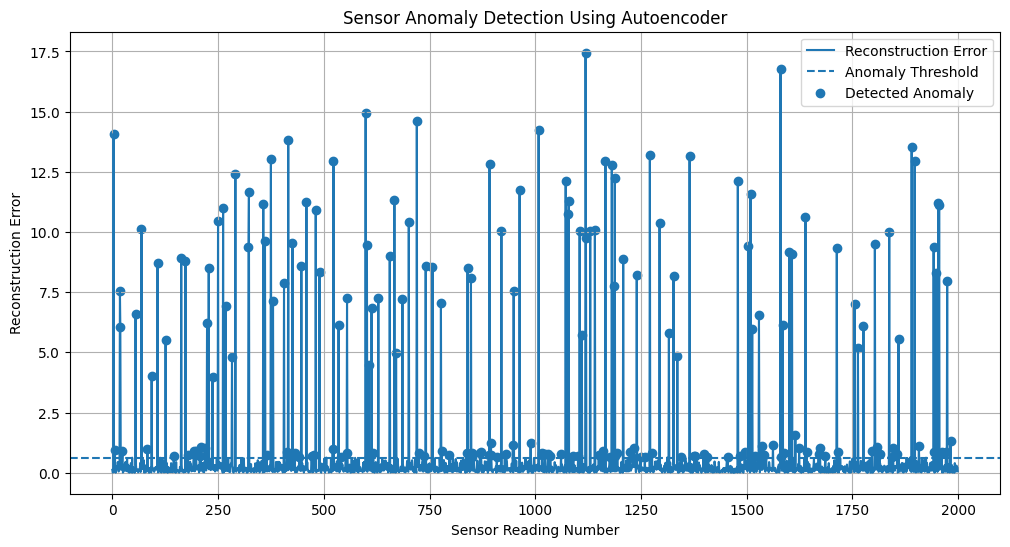

In [16]:
# STEP 14: Visualize detected anomalies

plt.figure(figsize=(12, 6))

plt.plot(
    data.index,
    data["Reconstruction_Error"],
    label="Reconstruction Error"
)

# Plot threshold
plt.axhline(
    y=threshold,
    linestyle="--",
    label="Anomaly Threshold"
)

# Highlight predicted anomalies
detected = data[data["Predicted_Anomaly"] == 1]

plt.scatter(
    detected.index,
    detected["Reconstruction_Error"],
    label="Detected Anomaly"
)

plt.xlabel("Sensor Reading Number")
plt.ylabel("Reconstruction Error")
plt.title("Sensor Anomaly Detection Using Autoencoder")
plt.legend()
plt.grid(True)

plt.show()

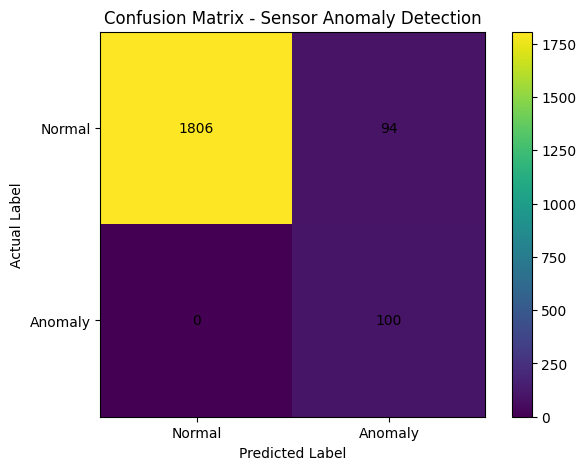

In [17]:
# STEP 15: Plot confusion matrix

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Sensor Anomaly Detection")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Normal", "Anomaly"])
plt.yticks([0, 1], ["Normal", "Anomaly"])

# Display numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()

plt.show()

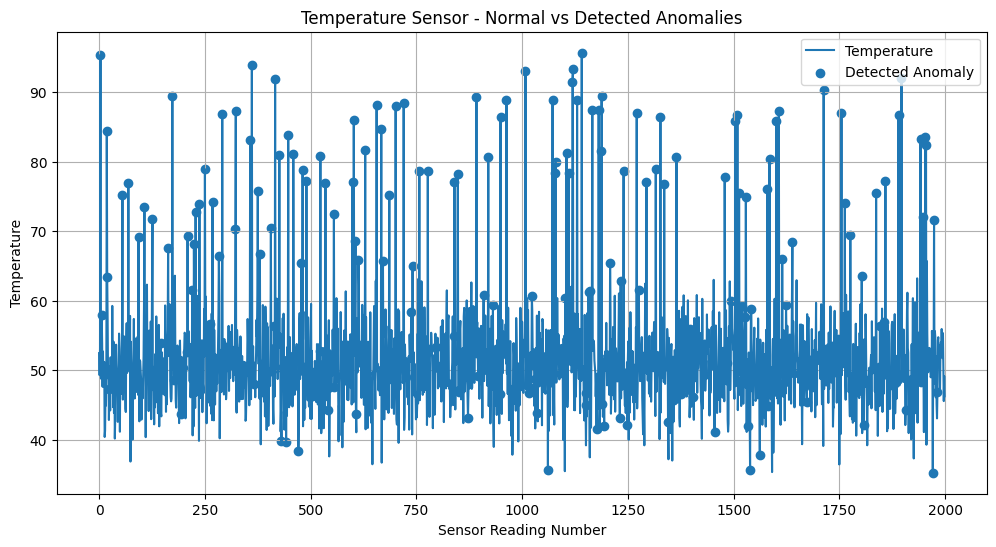

In [18]:
# STEP 16: Visualize normal and detected anomalous temperature readings

plt.figure(figsize=(12, 6))

# Plot all temperature readings
plt.plot(
    data.index,
    data["Temperature"],
    label="Temperature"
)

# Get detected anomalies
detected_anomalies = data[data["Predicted_Anomaly"] == 1]

# Highlight detected anomalies
plt.scatter(
    detected_anomalies.index,
    detected_anomalies["Temperature"],
    label="Detected Anomaly"
)

plt.xlabel("Sensor Reading Number")
plt.ylabel("Temperature")
plt.title("Temperature Sensor - Normal vs Detected Anomalies")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
# STEP 17: Create final results table

results = data[[
    "Temperature",
    "Pressure",
    "Vibration",
    "Humidity",
    "Anomaly",
    "Reconstruction_Error",
    "Predicted_Anomaly"
]].copy()

# Add readable labels
results["Actual_Result"] = results["Anomaly"].map({
    0: "Normal",
    1: "Anomaly"
})

results["Predicted_Result"] = results["Predicted_Anomaly"].map({
    0: "Normal",
    1: "Anomaly"
})

print("Final Results:")
results.head(10)

Final Results:


,Temperature,Pressure,Vibration,Humidity,Anomaly,Reconstruction_Error,Predicted_Anomaly,Actual_Result,Predicted_Result
0,52.483571,94.598574,17.409519,48.859186,0,0.119621,0,Normal,Normal
1,49.308678,98.843851,19.906390,53.690692,0,0.007365,0,Normal,Normal
2,53.238443,93.660641,20.054051,50.579398,0,0.016085,0,Normal,Normal
3,95.346881,147.424928,36.685370,82.033760,1,14.090496,1,Anomaly,Anomaly
4,48.829233,84.851083,15.899425,57.858497,0,0.569540,0,Normal,Normal
5,48.829315,101.706350,21.777702,68.371545,0,0.053107,0,Normal,Normal
6,57.896064,100.009644,11.886825,56.788410,0,0.929131,1,Normal,Anomaly
7,53.837174,93.463291,18.110346,44.143743,0,0.095426,0,Normal,Normal
8,47.652628,105.273965,18.535178,71.400678,0,0.002369,0,Normal,Normal
9,52.712800,107.500561,21.899980,51.629099,0,0.166887,0,Normal,Normal


In [20]:
# STEP 18: Final model performance

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("========== FINAL MODEL RESULTS ==========")
print(f"Accuracy  : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score  : {f1:.4f} ({f1 * 100:.2f}%)")
print("==========================================")

========== FINAL MODEL RESULTS ==========
Accuracy  : 0.9530 (95.30%)
Precision : 0.5155 (51.55%)
Recall    : 1.0000 (100.00%)
F1-Score  : 0.6803 (68.03%)


In [21]:
# STEP 19: Test a new sensor reading

# Enter a new sensor reading
new_sensor = np.array([[50, 100, 20, 60]])

# Scale the new reading using the same scaler
new_sensor_scaled = scaler.transform(new_sensor)

# Reconstruct using the trained Autoencoder
new_sensor_reconstructed = autoencoder.predict(new_sensor_scaled)

# Calculate reconstruction error
new_error = np.mean(
    np.square(new_sensor_scaled - new_sensor_reconstructed)
)

print("New Sensor Reading:")
print("Temperature:", new_sensor[0][0])
print("Pressure:", new_sensor[0][1])
print("Vibration:", new_sensor[0][2])
print("Humidity:", new_sensor[0][3])

print("\nReconstruction Error:", new_error)
print("Anomaly Threshold:", threshold)

# Make prediction
if new_error > threshold:
    print("\nResult: ANOMALY DETECTED")
else:
    print("\nResult: NORMAL SENSOR READING")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
New Sensor Reading:
Temperature: 50
Pressure: 100
Vibration: 20
Humidity: 60

Reconstruction Error: 0.0007156501231787542
Anomaly Threshold: 0.6292198941928034

Result: NORMAL SENSOR READING


In [22]:
# STEP 20: Test an abnormal sensor reading

# Abnormal sensor values
abnormal_sensor = np.array([[90, 150, 45, 95]])

# Scale using the same scaler used during training
abnormal_scaled = scaler.transform(abnormal_sensor)

# Reconstruct the abnormal reading
abnormal_reconstructed = autoencoder.predict(abnormal_scaled)

# Calculate reconstruction error
abnormal_error = np.mean(
    np.square(abnormal_scaled - abnormal_reconstructed)
)

print("Abnormal Sensor Reading:")
print("Temperature:", abnormal_sensor[0][0])
print("Pressure:", abnormal_sensor[0][1])
print("Vibration:", abnormal_sensor[0][2])
print("Humidity:", abnormal_sensor[0][3])

print("\nReconstruction Error:", abnormal_error)
print("Anomaly Threshold:", threshold)

# Prediction
if abnormal_error > threshold:
    print("\n🚨 RESULT: ANOMALY DETECTED")
else:
    print("\n✅ RESULT: NORMAL SENSOR READING")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Abnormal Sensor Reading:
Temperature: 90
Pressure: 150
Vibration: 45
Humidity: 95

Reconstruction Error: 17.851393843206925
Anomaly Threshold: 0.6292198941928034

🚨 RESULT: ANOMALY DETECTED


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
# STEP 21: Save the trained Autoencoder

autoencoder.save("sensor_anomaly_autoencoder.keras")

print("Model saved successfully!")

Model saved successfully!


In [24]:
# STEP 22: Download the trained model

from google.colab import files

files.download("sensor_anomaly_autoencoder.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# STEP 23: Live sensor anomaly prediction

def predict_sensor_status(temperature, pressure, vibration, humidity):

    # Create sensor input
    sensor_input = np.array([
        [temperature, pressure, vibration, humidity]
    ])

    # Scale the input
    sensor_scaled = scaler.transform(sensor_input)

    # Reconstruct using Autoencoder
    reconstructed = autoencoder.predict(
        sensor_scaled,
        verbose=0
    )

    # Calculate reconstruction error
    error = np.mean(
        np.square(sensor_scaled - reconstructed)
    )

    # Compare with threshold
    if error > threshold:
        result = "ANOMALY DETECTED"
    else:
        result = "NORMAL"

    print("================================")
    print("     SENSOR ANOMALY DETECTOR")
    print("================================")
    print(f"Temperature : {temperature}")
    print(f"Pressure    : {pressure}")
    print(f"Vibration  : {vibration}")
    print(f"Humidity    : {humidity}")
    print("--------------------------------")
    print(f"Reconstruction Error: {error:.4f}")
    print(f"Threshold           : {threshold:.4f}")
    print("--------------------------------")
    print("RESULT:", result)
    print("================================")

    return result

In [26]:
# Test with normal sensor values

predict_sensor_status(
    50,
    100,
    20,
    60
)

     SENSOR ANOMALY DETECTOR
Temperature : 50
Pressure    : 100
Vibration  : 20
Humidity    : 60
--------------------------------
Reconstruction Error: 0.0007
Threshold           : 0.6292
--------------------------------
RESULT: NORMAL


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'NORMAL'

In [27]:
# Test with abnormal sensor values

predict_sensor_status(
    90,
    150,
    45,
    95
)

     SENSOR ANOMALY DETECTOR
Temperature : 90
Pressure    : 150
Vibration  : 45
Humidity    : 95
--------------------------------
Reconstruction Error: 17.8514
Threshold           : 0.6292
--------------------------------
RESULT: ANOMALY DETECTED


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'ANOMALY DETECTED'

In [28]:
# STEP 24: Basic Exploratory Data Analysis

print("Dataset Information")
print("===================")

print("Number of readings:", len(data))
print("Number of features:", 4)

print("\nSensor Statistics:")
display(
    data[[
        "Temperature",
        "Pressure",
        "Vibration",
        "Humidity"
    ]].describe()
)

Dataset Information
Number of readings: 2000
Number of features: 4

Sensor Statistics:


,Temperature,Pressure,Vibration,Humidity
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,51.715900,101.936306,20.634248,61.213439
std,8.221204,11.798103,4.675761,11.740360
min,35.298057,75.843903,10.469889,23.116347
25%,47.129078,94.899588,18.032186,53.197464
50%,50.550793,100.612447,20.058088,60.322907
75%,54.092226,106.487585,22.188612,68.532112
max,95.633594,165.104781,45.053507,110.122292


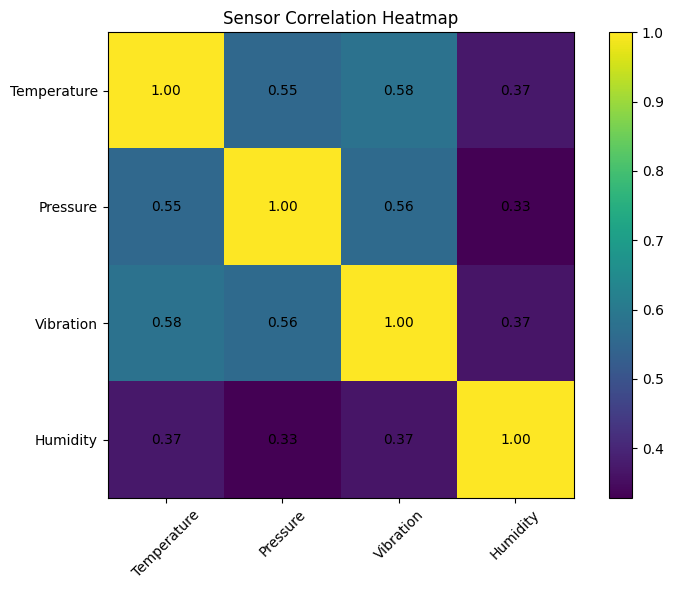

In [29]:
# STEP 25: Sensor correlation analysis

sensor_columns = [
    "Temperature",
    "Pressure",
    "Vibration",
    "Humidity"
]

correlation = data[sensor_columns].corr()

plt.figure(figsize=(8, 6))

plt.imshow(correlation, interpolation="nearest")

plt.title("Sensor Correlation Heatmap")
plt.xticks(
    range(len(sensor_columns)),
    sensor_columns,
    rotation=45
)
plt.yticks(
    range(len(sensor_columns)),
    sensor_columns
)

plt.colorbar()

# Display correlation values
for i in range(len(sensor_columns)):
    for j in range(len(sensor_columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

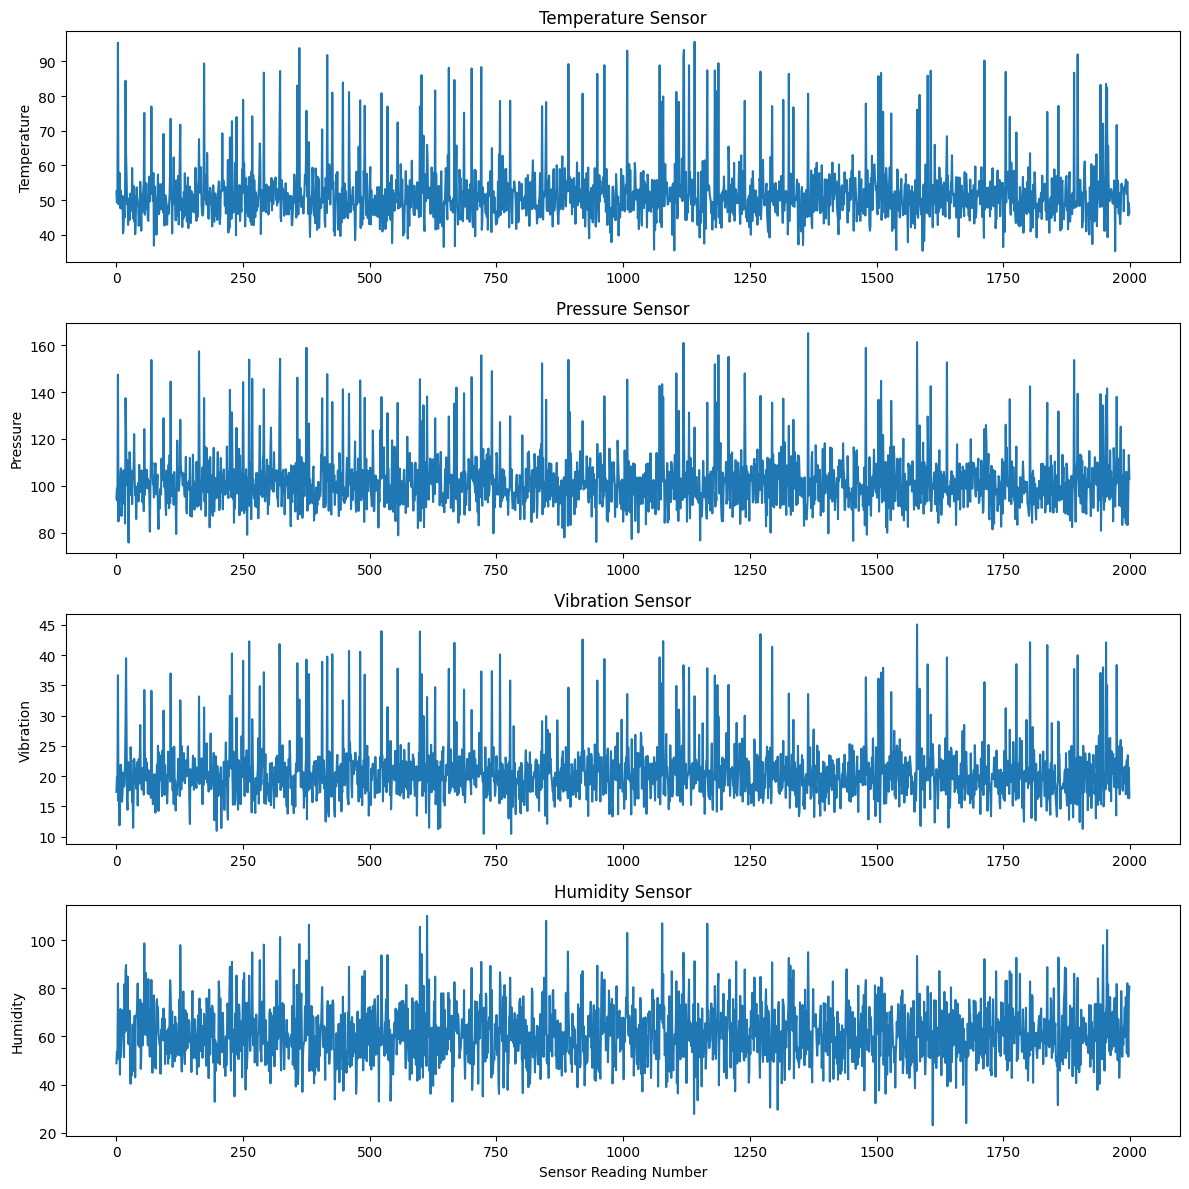

In [30]:
# STEP 26: Plot sensor trends

fig, axes = plt.subplots(4, 1, figsize=(12, 12))

axes[0].plot(data.index, data["Temperature"])
axes[0].set_title("Temperature Sensor")
axes[0].set_ylabel("Temperature")

axes[1].plot(data.index, data["Pressure"])
axes[1].set_title("Pressure Sensor")
axes[1].set_ylabel("Pressure")

axes[2].plot(data.index, data["Vibration"])
axes[2].set_title("Vibration Sensor")
axes[2].set_ylabel("Vibration")

axes[3].plot(data.index, data["Humidity"])
axes[3].set_title("Humidity Sensor")
axes[3].set_ylabel("Humidity")
axes[3].set_xlabel("Sensor Reading Number")

plt.tight_layout()
plt.show()

In [31]:
# STEP 27: Create time-series windows

sensor_data = data[
    ["Temperature", "Pressure", "Vibration", "Humidity"]
].values

window_size = 30

X_sequences = []

for i in range(len(sensor_data) - window_size + 1):
    window = sensor_data[i:i + window_size]
    X_sequences.append(window)

X_sequences = np.array(X_sequences)

print("Time-series windows created successfully!")
print("Number of windows:", X_sequences.shape[0])
print("Window size:", X_sequences.shape[1])
print("Number of sensors:", X_sequences.shape[2])

Time-series windows created successfully!
Number of windows: 1971
Window size: 30
Number of sensors: 4


In [32]:
# STEP 28: Normalize time-series sensor data

scaler_lstm = StandardScaler()

sensor_scaled = scaler_lstm.fit_transform(sensor_data)

X_sequences_scaled = []

for i in range(len(sensor_scaled) - window_size + 1):
    window = sensor_scaled[i:i + window_size]
    X_sequences_scaled.append(window)

X_sequences_scaled = np.array(X_sequences_scaled)

print("Scaled time-series data shape:")
print(X_sequences_scaled.shape)

Scaled time-series data shape:
(1971, 30, 4)


In [33]:
# STEP 29: Split time-series data

split_index = int(len(X_sequences_scaled) * 0.8)

X_lstm_train = X_sequences_scaled[:split_index]
X_lstm_test = X_sequences_scaled[split_index:]

print("LSTM training shape:", X_lstm_train.shape)
print("LSTM testing shape:", X_lstm_test.shape)

LSTM training shape: (1576, 30, 4)
LSTM testing shape: (395, 30, 4)


In [34]:
# STEP 30: Build LSTM Autoencoder

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

# Input shape: 30 time steps × 4 sensors
lstm_input = Input(shape=(window_size, 4))

# Encoder
encoded = LSTM(64, activation="tanh")(lstm_input)

# Latent representation
latent = Dense(32, activation="relu")(encoded)

# Repeat latent representation for each time step
repeated = RepeatVector(window_size)(latent)

# Decoder
decoded = LSTM(64, activation="tanh", return_sequences=True)(repeated)

# Reconstruct the 4 sensor values at every time step
output = TimeDistributed(
    Dense(4, activation="linear")
)(decoded)

# Create model
lstm_autoencoder = Model(lstm_input, output)

# Compile
lstm_autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

# Display architecture
lstm_autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 4)          │           260 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,836 (175.14 KB)

 Trainable params: 44,836 (175.14 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# STEP 31: Train the LSTM Autoencoder

early_stopping_lstm = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

lstm_history = lstm_autoencoder.fit(
    X_lstm_train,
    X_lstm_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping_lstm],
    verbose=1
)

print("LSTM Autoencoder training completed!")

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - loss: 1.0246 - val_loss: 0.8770
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 1.0039 - val_loss: 0.8643
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.9895 - val_loss: 0.8577
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.9773 - val_loss: 0.8477
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.9642 - val_loss: 0.8435
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.9550 - val_loss: 0.8413
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.9487 - val_loss: 0.8372
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.9339 - val_loss: 0.8330
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.9325 - val_loss: 0.8445
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.9212 - val_loss: 0.8319
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.9020 - val_loss: 0.8338
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.

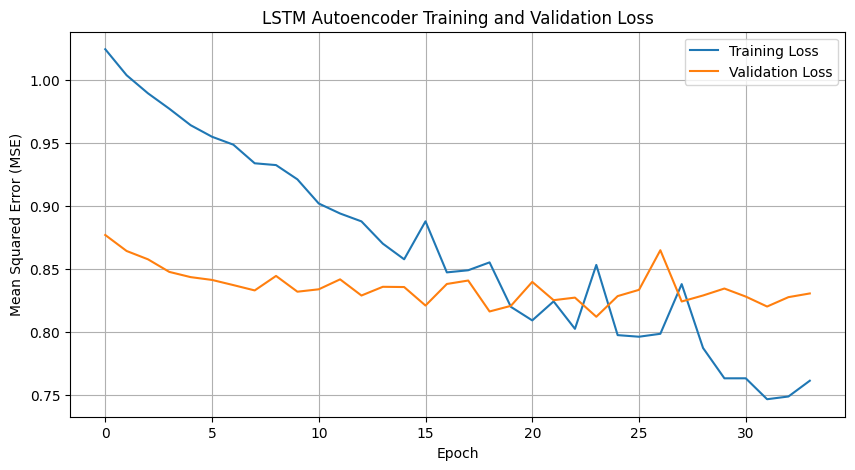

In [36]:
# STEP 32: Plot LSTM Autoencoder training loss

plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("LSTM Autoencoder Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
# STEP 33: Calculate LSTM reconstruction error

X_lstm_reconstructed = lstm_autoencoder.predict(
    X_sequences_scaled,
    verbose=0
)

# Calculate error for every time window
lstm_errors = np.mean(
    np.square(
        X_sequences_scaled - X_lstm_reconstructed
    ),
    axis=(1, 2)
)

print("LSTM reconstruction error calculated!")
print("Number of windows:", len(lstm_errors))
print("Minimum error:", np.min(lstm_errors))
print("Maximum error:", np.max(lstm_errors))
print("Mean error:", np.mean(lstm_errors))

LSTM reconstruction error calculated!
Number of windows: 1971
Minimum error: 0.35123814732980724
Maximum error: 2.021767590932547
Mean error: 0.840044642958227


In [38]:
# STEP 34: Calculate LSTM anomaly threshold

# Use the training portion of the reconstruction errors
lstm_train_errors = lstm_errors[:split_index]

# Set threshold at the 95th percentile
lstm_threshold = np.percentile(lstm_train_errors, 95)

print("LSTM Anomaly Threshold:", lstm_threshold)

LSTM Anomaly Threshold: 1.5760112976560776


In [39]:
# STEP 35: Detect anomalies using LSTM Autoencoder

lstm_predictions = (
    lstm_errors > lstm_threshold
).astype(int)

print("LSTM anomaly detection completed!")

print("Normal windows:",
      np.sum(lstm_predictions == 0))

print("Anomalous windows:",
      np.sum(lstm_predictions == 1))

LSTM anomaly detection completed!
Normal windows: 1863
Anomalous windows: 108


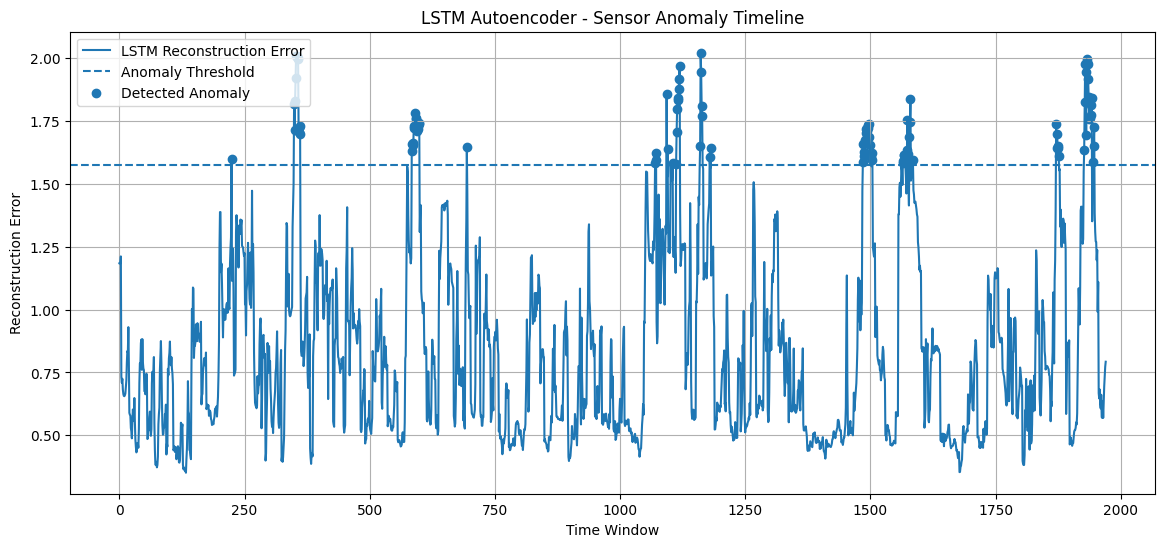

In [40]:
# STEP 36: LSTM anomaly timeline

plt.figure(figsize=(14, 6))

# Plot reconstruction error
plt.plot(
    lstm_errors,
    label="LSTM Reconstruction Error"
)

# Plot threshold
plt.axhline(
    y=lstm_threshold,
    linestyle="--",
    label="Anomaly Threshold"
)

# Find anomalous windows
anomaly_windows = np.where(lstm_predictions == 1)[0]

# Highlight anomalies
plt.scatter(
    anomaly_windows,
    lstm_errors[anomaly_windows],
    label="Detected Anomaly"
)

plt.xlabel("Time Window")
plt.ylabel("Reconstruction Error")
plt.title("LSTM Autoencoder - Sensor Anomaly Timeline")
plt.legend()
plt.grid(True)

plt.show()

In [41]:
# STEP 37: Find most anomalous time windows

top_anomalies = np.argsort(
    lstm_errors
)[-10:][::-1]

anomaly_results = pd.DataFrame({
    "Time_Window": top_anomalies,
    "Reconstruction_Error": lstm_errors[top_anomalies]
})

print("Top 10 Most Anomalous Time Windows:")
display(anomaly_results)

Top 10 Most Anomalous Time Windows:


,Time_Window,Reconstruction_Error
0,1161,2.021768
1,355,2.007675
2,353,2.007150
3,354,2.004974
4,356,2.000741
5,357,1.996017
6,1932,1.994913
7,1933,1.985477
8,1934,1.977924
9,1929,1.977465


In [42]:
# STEP 38: Compare the two Autoencoder models

print("========== MODEL COMPARISON ==========")

print("\n1. Dense Autoencoder")
print("---------------------")
print("Input: Individual sensor reading")
print("Features: 4 sensors")
print("Architecture: Dense Encoder + Dense Decoder")
print("Purpose: Detect unusual individual readings")

print("\n2. LSTM Autoencoder")
print("--------------------")
print("Input: 30 consecutive sensor readings")
print("Features: 4 sensors")
print("Architecture: LSTM Encoder + LSTM Decoder")
print("Purpose: Detect unusual temporal patterns")

print("\n======================================")

========== MODEL COMPARISON ==========

1. Dense Autoencoder
---------------------
Input: Individual sensor reading
Features: 4 sensors
Architecture: Dense Encoder + Dense Decoder
Purpose: Detect unusual individual readings

2. LSTM Autoencoder
--------------------
Input: 30 consecutive sensor readings
Features: 4 sensors
Architecture: LSTM Encoder + LSTM Decoder
Purpose: Detect unusual temporal patterns



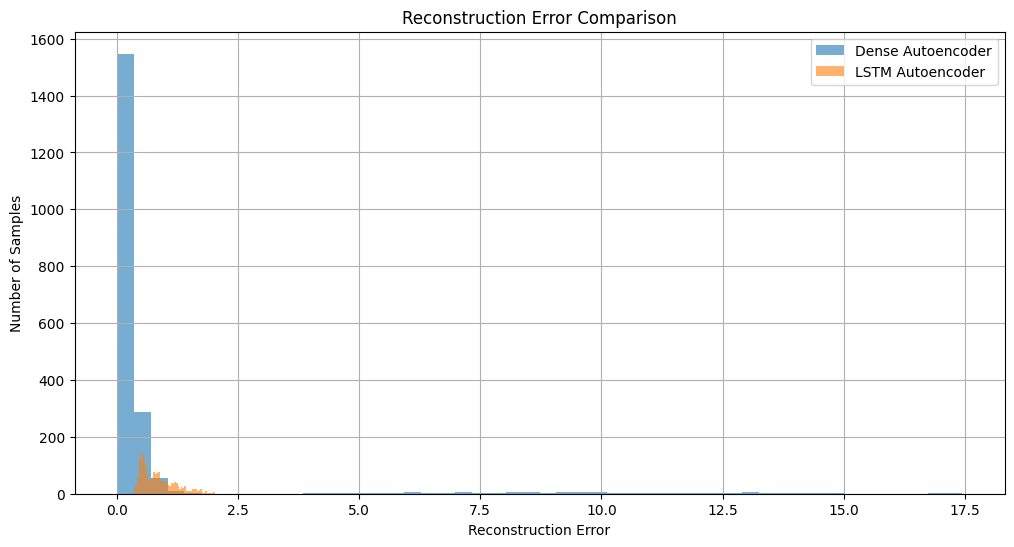

In [43]:
# STEP 39: Compare reconstruction error distributions

plt.figure(figsize=(12, 6))

plt.hist(
    reconstruction_error,
    bins=50,
    alpha=0.6,
    label="Dense Autoencoder"
)

plt.hist(
    lstm_errors,
    bins=50,
    alpha=0.6,
    label="LSTM Autoencoder"
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Reconstruction Error Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [44]:
# STEP 40: Model comparison table

comparison = pd.DataFrame({
    "Model": [
        "Dense Autoencoder",
        "LSTM Autoencoder"
    ],
    "Input Type": [
        "Single sensor reading",
        "30-reading time window"
    ],
    "Deep Learning": [
        "Yes",
        "Yes"
    ],
    "Temporal Learning": [
        "No",
        "Yes"
    ],
    "Main Use": [
        "Point anomaly detection",
        "Time-series anomaly detection"
    ]
})

display(comparison)

,Model,Input Type,Deep Learning,Temporal Learning,Main Use
0,Dense Autoencoder,Single sensor reading,Yes,No,Point anomaly detection
1,LSTM Autoencoder,30-reading time window,Yes,Yes,Time-series anomaly detection


In [45]:
# STEP 41: Sensor-wise anomaly contribution

sensor_names = [
    "Temperature",
    "Pressure",
    "Vibration",
    "Humidity"
]

# Select the most anomalous time window
most_anomalous_window = np.argmax(lstm_errors)

original_window = X_sequences_scaled[most_anomalous_window]
reconstructed_window = X_lstm_reconstructed[most_anomalous_window]

# Calculate error for each sensor
sensor_errors = np.mean(
    np.square(original_window - reconstructed_window),
    axis=0
)

sensor_contribution = pd.DataFrame({
    "Sensor": sensor_names,
    "Reconstruction_Error": sensor_errors
})

# Calculate percentage contribution
sensor_contribution["Contribution_%"] = (
    sensor_contribution["Reconstruction_Error"]
    / sensor_contribution["Reconstruction_Error"].sum()
) * 100

sensor_contribution = sensor_contribution.sort_values(
    "Reconstruction_Error",
    ascending=False
)

print("Sensor-wise anomaly contribution:")
display(sensor_contribution)

Sensor-wise anomaly contribution:


,Sensor,Reconstruction_Error,Contribution_%
0,Temperature,2.923710,36.152889
1,Pressure,2.190455,27.085896
2,Vibration,1.865392,23.066346
3,Humidity,1.107514,13.694870


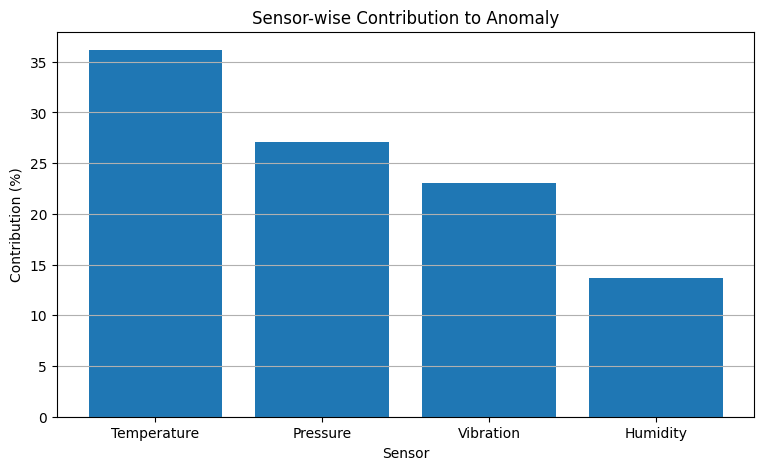

In [46]:
# STEP 42: Plot sensor-wise anomaly contribution

plt.figure(figsize=(9, 5))

plt.bar(
    sensor_contribution["Sensor"],
    sensor_contribution["Contribution_%"]
)

plt.xlabel("Sensor")
plt.ylabel("Contribution (%)")
plt.title("Sensor-wise Contribution to Anomaly")
plt.grid(axis="y")

plt.show()

In [47]:
# STEP 43: Interactive Sensor Monitoring Dashboard

import ipywidgets as widgets
from IPython.display import display, clear_output

# Create input boxes
temperature_input = widgets.FloatText(
    value=50,
    description="Temperature:"
)

pressure_input = widgets.FloatText(
    value=100,
    description="Pressure:"
)

vibration_input = widgets.FloatText(
    value=20,
    description="Vibration:"
)

humidity_input = widgets.FloatText(
    value=60,
    description="Humidity:"
)

predict_button = widgets.Button(
    description="Predict Sensor Status"
)

output = widgets.Output()


def predict_button_clicked(button):

    with output:
        clear_output()

        sensor_input = np.array([[
            temperature_input.value,
            pressure_input.value,
            vibration_input.value,
            humidity_input.value
        ]])

        # Scale sensor data
        sensor_scaled = scaler.transform(sensor_input)

        # Reconstruct
        reconstructed = autoencoder.predict(
            sensor_scaled,
            verbose=0
        )

        # Reconstruction error
        error = np.mean(
            np.square(sensor_scaled - reconstructed)
        )

        print("======================================")
        print("       SENSOR MONITORING SYSTEM")
        print("======================================")

        print(f"Temperature : {temperature_input.value}")
        print(f"Pressure    : {pressure_input.value}")
        print(f"Vibration   : {vibration_input.value}")
        print(f"Humidity    : {humidity_input.value}")

        print("--------------------------------------")
        print(f"Reconstruction Error : {error:.4f}")
        print(f"Threshold            : {threshold:.4f}")
        print("--------------------------------------")

        if error > threshold:
            print("🚨 STATUS: ANOMALY DETECTED")
        else:
            print("✅ STATUS: NORMAL")

        print("======================================")


predict_button.on_click(predict_button_clicked)

display(
    temperature_input,
    pressure_input,
    vibration_input,
    humidity_input,
    predict_button,
    output
)

FloatText(value=50.0, description='Temperature:')

FloatText(value=100.0, description='Pressure:')

FloatText(value=20.0, description='Vibration:')

FloatText(value=60.0, description='Humidity:')

Button(description='Predict Sensor Status', style=ButtonStyle())

Output()

In [51]:
# STEP 44: Anomaly severity classification

def classify_severity(error, threshold):

    if error <= threshold:
        return "NORMAL"

    elif error <= threshold * 2:
        return "WARNING"

    else:
        return "CRITICAL"


# Test the severity system
test_errors = [
    threshold * 0.5,
    threshold * 1.5,
    threshold * 3
]

for error in test_errors:

    severity = classify_severity(error, threshold)
    record_prediction(
    temperature_input.value,
    pressure_input.value,
    vibration_input.value,
    humidity_input.value,
    error,
    severity
)

    print(f"Reconstruction Error: {error:.4f}")
    print("Severity:", severity)
    print("--------------------------------")

Reconstruction Error: 0.3146
Severity: NORMAL
--------------------------------
Reconstruction Error: 0.9438
Severity: WARNING
--------------------------------
Reconstruction Error: 1.8877
Severity: CRITICAL
--------------------------------


In [49]:
# STEP 44: Anomaly severity classification

def classify_severity(error, threshold):

    if error <= threshold:
        return "NORMAL"

    elif error <= threshold * 2:
        return "WARNING"

    else:
        return "CRITICAL"


# Test the severity system
test_errors = [
    threshold * 0.5,
    threshold * 1.5,
    threshold * 3
]

for error in test_errors:

    severity = classify_severity(error, threshold)

    print(f"Reconstruction Error: {error:.4f}")
    print("Severity:", severity)
    print("--------------------------------")

Reconstruction Error: 0.3146
Severity: NORMAL
--------------------------------
Reconstruction Error: 0.9438
Severity: WARNING
--------------------------------
Reconstruction Error: 1.8877
Severity: CRITICAL
--------------------------------


In [50]:
# STEP 45: Create anomaly history

anomaly_history = []


def record_prediction(
    temperature,
    pressure,
    vibration,
    humidity,
    error,
    severity
):
    anomaly_history.append({
        "Temperature": temperature,
        "Pressure": pressure,
        "Vibration": vibration,
        "Humidity": humidity,
        "Reconstruction_Error": error,
        "Severity": severity
    })


def show_anomaly_history():

    if len(anomaly_history) == 0:
        print("No predictions recorded yet.")
        return

    history_df = pd.DataFrame(anomaly_history)

    print("========== SENSOR ANOMALY HISTORY ==========")
    display(history_df)

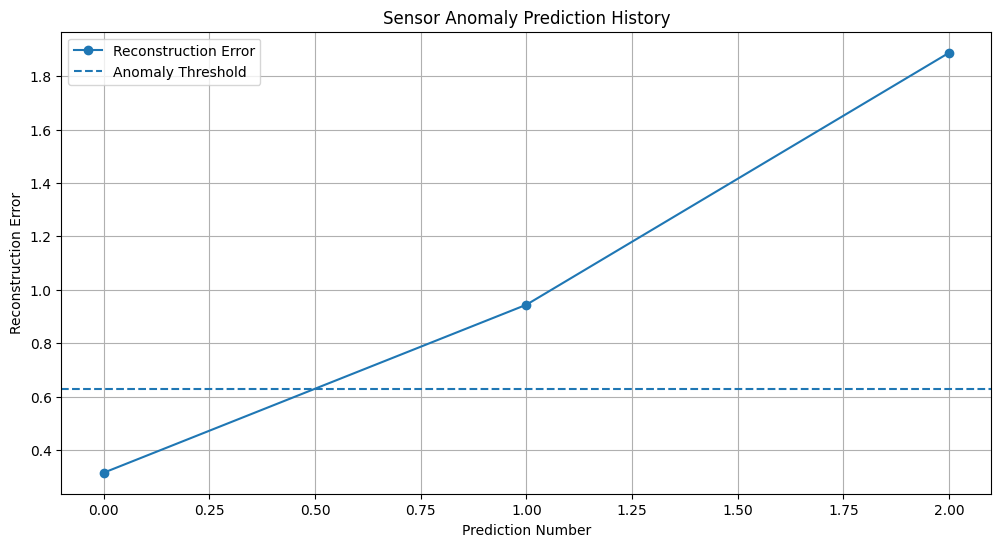

In [52]:
# STEP 46: Visualize anomaly history

if len(anomaly_history) == 0:
    print("No prediction history available.")
else:
    history_df = pd.DataFrame(anomaly_history)

    plt.figure(figsize=(12, 6))

    plt.plot(
        history_df.index,
        history_df["Reconstruction_Error"],
        marker="o",
        label="Reconstruction Error"
    )

    plt.axhline(
        y=threshold,
        linestyle="--",
        label="Anomaly Threshold"
    )

    plt.xlabel("Prediction Number")
    plt.ylabel("Reconstruction Error")
    plt.title("Sensor Anomaly Prediction History")
    plt.legend()
    plt.grid(True)

    plt.show()

In [53]:
# STEP 47: Save LSTM model and scaler

import joblib

# Save the LSTM Autoencoder
lstm_autoencoder.save("lstm_sensor_anomaly_model.keras")

# Save the scaler
joblib.dump(scaler_lstm, "sensor_scaler.pkl")

# Save the threshold
joblib.dump(lstm_threshold, "lstm_threshold.pkl")

print("======================================")
print("LSTM model saved successfully!")
print("Scaler saved successfully!")
print("Threshold saved successfully!")
print("======================================")

LSTM model saved successfully!
Scaler saved successfully!
Threshold saved successfully!


In [55]:
# STEP 48: Download project model files

from google.colab import files

files.download("lstm_sensor_anomaly_model.keras")
files.download("sensor_scaler.pkl")
files.download("lstm_threshold.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
# STEP 49: Final project results summary

final_results = pd.DataFrame({
    "Metric": [
        "Dense Autoencoder Accuracy",
        "Dense Autoencoder Precision",
        "Dense Autoencoder Recall",
        "Dense Autoencoder F1-Score",
        "LSTM Autoencoder Threshold",
        "LSTM Number of Windows",
        "LSTM Detected Anomalies"
    ],
    "Value": [
        f"{accuracy * 100:.2f}%",
        f"{precision * 100:.2f}%",
        f"{recall * 100:.2f}%",
        f"{f1 * 100:.2f}%",
        f"{lstm_threshold:.6f}",
        len(lstm_errors),
        int(np.sum(lstm_predictions))
    ]
})

print("========== FINAL PROJECT RESULTS ==========")
display(final_results)

========== FINAL PROJECT RESULTS ==========


,Metric,Value
0,Dense Autoencoder Accuracy,95.30%
1,Dense Autoencoder Precision,51.55%
2,Dense Autoencoder Recall,100.00%
3,Dense Autoencoder F1-Score,68.03%
4,LSTM Autoencoder Threshold,1.576011
5,LSTM Number of Windows,1971
6,LSTM Detected Anomalies,108


In [57]:
# STEP 50: Project completion summary

print("""
========================================================
 DEEP LEARNING-BASED SENSOR ANOMALY DETECTION SYSTEM
========================================================

1. Sensor Dataset                  ✓
2. Data Preprocessing              ✓
3. Exploratory Data Analysis       ✓
4. Sensor Correlation Analysis     ✓
5. Dense Autoencoder               ✓
6. Reconstruction Error            ✓
7. Threshold-Based Detection       ✓
8. Model Evaluation                ✓
9. Time-Series Window Creation     ✓
10. LSTM Autoencoder               ✓
11. LSTM Reconstruction Error      ✓
12. LSTM Anomaly Detection         ✓
13. Sensor-Wise Analysis           ✓
14. Severity Classification        ✓
15. Interactive Monitoring         ✓
16. Anomaly History                ✓
17. Model Saving                   ✓
18. Final Results                  ✓

========================================================
 PROJECT DEVELOPMENT COMPLETED
========================================================
""")


 DEEP LEARNING-BASED SENSOR ANOMALY DETECTION SYSTEM

1. Sensor Dataset                  ✓
2. Data Preprocessing              ✓
3. Exploratory Data Analysis       ✓
4. Sensor Correlation Analysis     ✓
5. Dense Autoencoder               ✓
6. Reconstruction Error            ✓
7. Threshold-Based Detection       ✓
8. Model Evaluation                ✓
9. Time-Series Window Creation     ✓
10. LSTM Autoencoder               ✓
11. LSTM Reconstruction Error      ✓
12. LSTM Anomaly Detection         ✓
13. Sensor-Wise Analysis           ✓
14. Severity Classification        ✓
15. Interactive Monitoring         ✓
16. Anomaly History                ✓
17. Model Saving                   ✓
18. Final Results                  ✓

 PROJECT DEVELOPMENT COMPLETED

